# Bayesian Bootstrap for Paired Binary Outcomes

The **Bayesian bootstrap** (Rubin, 1981) is a nonparametric method for posterior inference that avoids specifying a parametric likelihood. Instead of resampling observations (as in the classical bootstrap), it draws random **Dirichlet weights** over the observed data.

## Setup

For paired binary observations $(X_i^{\text{before}}, X_i^{\text{after}})$, define the paired difference:

$$D_i = X_i^{\text{after}} - X_i^{\text{before}}, \quad D_i \in \{-1, 0, 1\}$$

Each posterior draw proceeds as:

1. Sample weights: $\mathbf{w} \sim \text{Dirichlet}(1, \dots, 1)$
2. Compute the weighted mean difference: $\Delta^{(s)} = \sum_{i=1}^{n} w_i \, D_i$

This yields a full posterior distribution over the average treatment effect $\Delta$.

## 1. Import Libraries and Define Classes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple

In [2]:
@dataclass
class BayesianBootstrapResult:
    """Container for Bayesian bootstrap posterior samples."""

    posterior_samples: np.ndarray
    posterior_mean: float
    credible_interval_95: Tuple[float, float]
    prob_difference_gt_zero: float

In [3]:
def bayesian_bootstrap_paired_binary(
    before: np.ndarray,
    after: np.ndarray,
    n_samples: int = 50_000,
    random_state: int | None = 42,
) -> BayesianBootstrapResult:
    """
    Bayesian bootstrap for paired binary outcomes.

    Parameters
    ----------
    before : np.ndarray
        Binary outcomes before treatment/intervention. Shape: (n,)
    after : np.ndarray
        Binary outcomes after treatment/intervention. Shape: (n,)
    n_samples : int
        Number of posterior bootstrap samples.
    random_state : int | None
        Random seed.

    Returns
    -------
    BayesianBootstrapResult
        Posterior samples and summary statistics.

    Notes
    -----
    For paired binary observations:
        D_i = after_i - before_i, where D_i in {-1, 0, 1}

    The Bayesian bootstrap samples random weights:
        w ~ Dirichlet(1, ..., 1)

    and computes posterior draws:
        Delta^(s) = sum_i w_i D_i
    """
    rng = np.random.default_rng(random_state)

    before = np.asarray(before, dtype=np.int64)
    after = np.asarray(after, dtype=np.int64)

    if before.shape != after.shape:
        raise ValueError("before and after must have identical shapes.")

    if not np.all(np.isin(before, [0, 1])):
        raise ValueError("before must contain only 0/1 values.")

    if not np.all(np.isin(after, [0, 1])):
        raise ValueError("after must contain only 0/1 values.")

    # Paired differences
    differences = after - before
    n_obs = differences.shape[0]

    posterior_samples = np.empty(n_samples)
    alpha = np.ones(n_obs)

    for s in range(n_samples):
        # Sample Bayesian bootstrap weights
        weights = rng.dirichlet(alpha)
        # Weighted average difference
        posterior_samples[s] = np.sum(weights * differences)

    posterior_mean = float(np.mean(posterior_samples))

    credible_interval_95 = (
        float(np.quantile(posterior_samples, 0.025)),
        float(np.quantile(posterior_samples, 0.975)),
    )

    prob_difference_gt_zero = float(np.mean(posterior_samples > 0.0))

    return BayesianBootstrapResult(
        posterior_samples=posterior_samples,
        posterior_mean=posterior_mean,
        credible_interval_95=credible_interval_95,
        prob_difference_gt_zero=prob_difference_gt_zero,
    )

## 2. Simulate Paired Binary Data

Create example paired binary arrays representing a treatment intervention scenario.

In [4]:
# Example paired binary observations
# before = baseline outcome, after = post-treatment outcome

before = np.array([0, 1, 1, 0, 1, 0, 0, 1, 1, 0])
after = np.array([1, 1, 0, 1, 1, 0, 1, 1, 0, 1])

print(f"Number of observations: {len(before)}")
print(f"Before: {before}")
print(f"After:  {after}")
print(f"Paired differences (D_i): {after - before}")

Number of observations: 10
Before: [0 1 1 0 1 0 0 1 1 0]
After:  [1 1 0 1 1 0 1 1 0 1]
Paired differences (D_i): [ 1  0 -1  1  0  0  1  0 -1  1]


## 3. Run Bayesian Bootstrap

In [5]:
result = bayesian_bootstrap_paired_binary(
    before=before,
    after=after,
    n_samples=20_000,
    random_state=123,
)

## 4. Inspect Posterior Summary Statistics

In [6]:
print("Bayesian Bootstrap for Paired Binary Data")
print("-" * 50)
print(f"Posterior mean difference:  {result.posterior_mean:.4f}")
print(f"95% credible interval:     ({result.credible_interval_95[0]:.4f}, {result.credible_interval_95[1]:.4f})")
print(f"P(Delta > 0 | data):       {result.prob_difference_gt_zero:.4f}")

Bayesian Bootstrap for Paired Binary Data
--------------------------------------------------
Posterior mean difference:  0.2010
95% credible interval:     (-0.2622, 0.6237)
P(Delta > 0 | data):       0.8154


## 5. Visualize Posterior Distribution

Histogram of posterior samples with the posterior mean (dashed line) and 95% credible interval (shaded region).

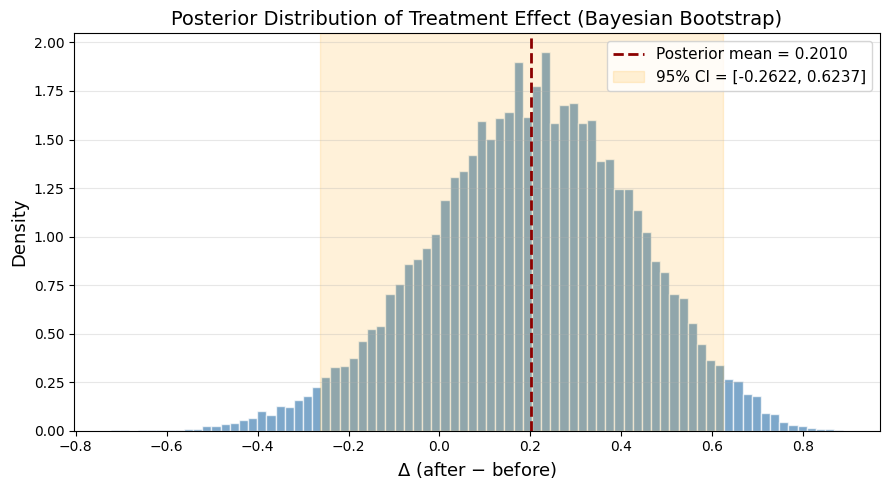

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(result.posterior_samples, bins=80, density=True, alpha=0.7, color="steelblue", edgecolor="white")

# Posterior mean
ax.axvline(result.posterior_mean, color="darkred", linestyle="--", linewidth=2, label=f"Posterior mean = {result.posterior_mean:.4f}")

# 95% credible interval
ci_lo, ci_hi = result.credible_interval_95
ax.axvspan(ci_lo, ci_hi, alpha=0.15, color="orange", label=f"95% CI = [{ci_lo:.4f}, {ci_hi:.4f}]")

ax.set_xlabel(r"$\Delta$ (after $-$ before)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title("Posterior Distribution of Treatment Effect (Bayesian Bootstrap)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Sensitivity Analysis: Varying Sample Size

Run the bootstrap with different `n_samples` values to check how the posterior mean and credible interval width stabilize.

In [8]:
sample_sizes = [1_000, 5_000, 10_000, 20_000, 50_000]

print(f"{'n_samples':>10}  {'Post. Mean':>12}  {'95% CI Width':>12}  {'P(Δ>0)':>8}")
print("-" * 50)

for n in sample_sizes:
    res = bayesian_bootstrap_paired_binary(
        before=before, after=after, n_samples=n, random_state=42
    )
    ci_width = res.credible_interval_95[1] - res.credible_interval_95[0]
    print(f"{n:>10,}  {res.posterior_mean:>12.4f}  {ci_width:>12.4f}  {res.prob_difference_gt_zero:>8.4f}")

 n_samples    Post. Mean  95% CI Width    P(Δ>0)
--------------------------------------------------
     1,000        0.1953        0.9523    0.8150
     5,000        0.1968        0.8940    0.8120
    10,000        0.2009        0.8960    0.8144
    20,000        0.1985        0.8858    0.8101
    50,000        0.1996        0.8799    0.8113


## 7. ROPE Analysis (Region of Practical Equivalence)

Instead of testing a point null $H_0: \Delta = 0$, we define a **ROPE** — a small interval $[-\epsilon, \epsilon]$ around zero that represents "practically equivalent to no effect."

We then compute three posterior probabilities:

| Decision | Condition |
|---|---|
| **Accept $H_0$** (practically zero) | $P(\Delta \in \text{ROPE} \mid \text{data}) > \tau$ |
| **Reject $H_0$** (meaningful effect) | $P(\Delta \notin \text{ROPE} \mid \text{data}) > \tau$ |
| **Undecided** | Neither threshold met |

where $\tau$ is a decision threshold (e.g., 0.95). A common ROPE half-width is $\epsilon = 0.05$.

In [9]:
rope_half_width = 0.05
rope = (-rope_half_width, rope_half_width)
decision_threshold = 0.95

samples = result.posterior_samples

# Posterior probabilities
p_in_rope = float(np.mean((samples >= rope[0]) & (samples <= rope[1])))
p_below_rope = float(np.mean(samples < rope[0]))
p_above_rope = float(np.mean(samples > rope[1]))

# Decision
if p_in_rope > decision_threshold:
    decision = "Accept H₀ — effect is practically zero"
elif (p_below_rope + p_above_rope) > decision_threshold:
    decision = "Reject H₀ — meaningful effect detected"
else:
    decision = "Undecided — need more data"

print(f"ROPE: [{rope[0]}, {rope[1]}]")
print(f"Decision threshold (τ): {decision_threshold}")
print("-" * 50)
print(f"P(Δ ∈ ROPE | data):     {p_in_rope:.4f}")
print(f"P(Δ < ROPE | data):     {p_below_rope:.4f}")
print(f"P(Δ > ROPE | data):     {p_above_rope:.4f}")
print("-" * 50)
print(f"Decision: {decision}")

ROPE: [-0.05, 0.05]
Decision threshold (τ): 0.95
--------------------------------------------------
P(Δ ∈ ROPE | data):     0.1093
P(Δ < ROPE | data):     0.1370
P(Δ > ROPE | data):     0.7537
--------------------------------------------------
Decision: Undecided — need more data


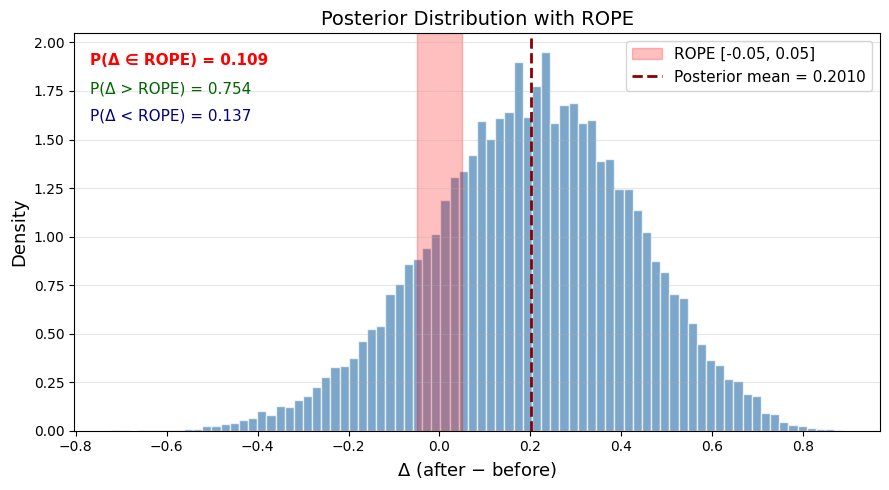

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(samples, bins=80, density=True, alpha=0.7, color="steelblue", edgecolor="white")

# ROPE region
ax.axvspan(rope[0], rope[1], alpha=0.25, color="red", label=f"ROPE [{rope[0]}, {rope[1]}]")

# Posterior mean
ax.axvline(result.posterior_mean, color="darkred", linestyle="--", linewidth=2,
           label=f"Posterior mean = {result.posterior_mean:.4f}")

# Annotate probabilities
ax.text(0.02, 0.95, f"P(Δ ∈ ROPE) = {p_in_rope:.3f}", transform=ax.transAxes,
        fontsize=11, verticalalignment="top", color="red", fontweight="bold")
ax.text(0.02, 0.88, f"P(Δ > ROPE) = {p_above_rope:.3f}", transform=ax.transAxes,
        fontsize=11, verticalalignment="top", color="darkgreen")
ax.text(0.02, 0.81, f"P(Δ < ROPE) = {p_below_rope:.3f}", transform=ax.transAxes,
        fontsize=11, verticalalignment="top", color="navy")

ax.set_xlabel(r"$\Delta$ (after $-$ before)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title("Posterior Distribution with ROPE", fontsize=14)
ax.legend(fontsize=11, loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()